Model Adı                 | Süre (Sn)  | Doğruluk   | F1 Skor
-----------------------------------------------------------------
Logistic Regression       | 0.863      | 0.731      | 0.733
Naive Bayes               | 0.339      | 0.521      | 0.645
Decision Tree             | 1.309      | 0.762      | 0.766
Random Forest             | 6.933      | 0.796      | 0.798
XGBoost                   | 1.188      | 0.792      | 0.798
LightGBM                  | 1.957      | 0.800      | 0.807
Yapay Sinir Agi (ANN)     | 71.172     | 0.701      | 0.704


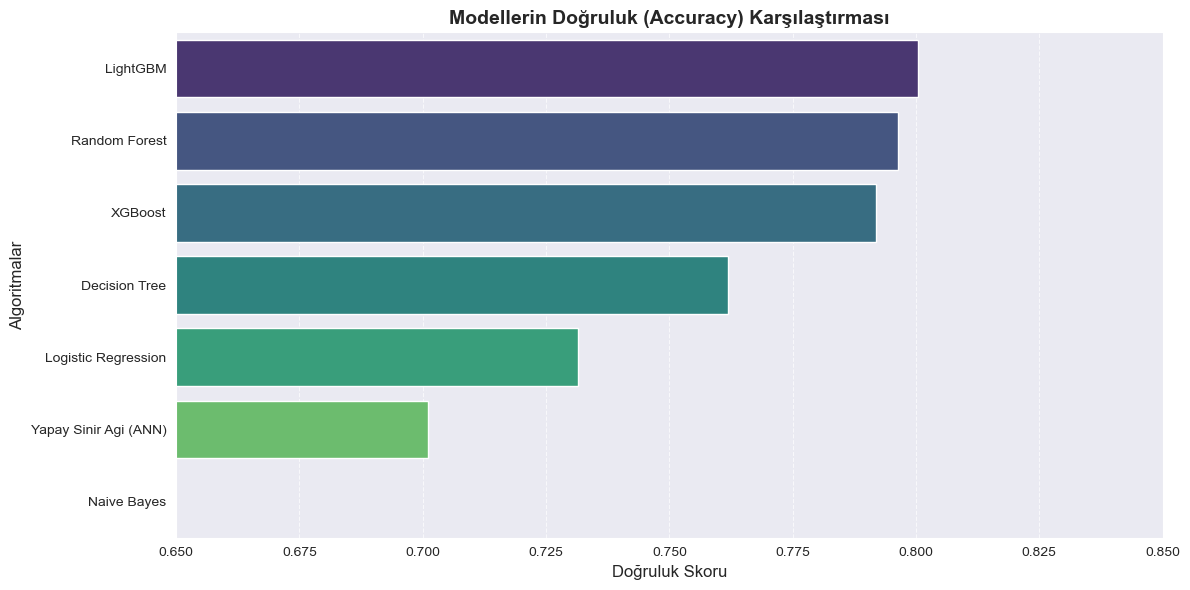

In [2]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier # <-- YAPAY SİNİR AĞI EKLENDİ!

# ---------------------------------------------------------
# 1. VERİ YÜKLEME VE AYIRMA (KESİN İZOLASYON)
# ---------------------------------------------------------
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

y_train_orijinal = train_df["Transported"]
test_ids = test_df["PassengerId"]

# Train ve Test'i tamamen ayırıyoruz
X_train = train_df.drop(["Transported", "PassengerId"], axis=1)
X_test = test_df.drop(["PassengerId"], axis=1)

# ---------------------------------------------------------
# 2. ÖZELLİK MÜHENDİSLİĞİ (FONKSİYON İLE)
# ---------------------------------------------------------
# Aynı işlemleri iki veriye de GÜVENLİ ve AYRI AYRI uygulamak için fonksiyon kullanıyoruz
def veriyi_isle(df):
    df = df.copy()
    # Harcamaları topla
    harcama_sutunlari = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[harcama_sutunlari] = df[harcama_sutunlari].fillna(0)
    df['Total_Spend'] = df[harcama_sutunlari].sum(axis=1)

    # Kabini parçala
    df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)

    # İşe yaramayanları at
    return df.drop(["Name", "Cabin"], axis=1, errors='ignore')

# Fonksiyonu iki veriye bağımsız olarak uyguluyoruz
X_train = veriyi_isle(X_train)
X_test = veriyi_isle(X_test)

# ---------------------------------------------------------
# 3. EKSİK VERİ DOLDURMA (DATA LEAKAGE ÖNLEME)
# ---------------------------------------------------------
sayisal_sutunlar = X_train.select_dtypes(include=['float64', 'int64']).columns
kategorik_sutunlar = X_train.select_dtypes(include=['object', 'bool']).columns

# KURAL: Doldurma değerlerini (Medyan/Mod) SADECE TRAIN'den öğren (Sızıntıyı engelle)
for col in sayisal_sutunlar:
    train_medyan = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_medyan).infer_objects(copy=False)
    X_test[col] = X_test[col].fillna(train_medyan).infer_objects(copy=False) # Testi train'in medyanıyla doldur!

for col in kategorik_sutunlar:
    train_mod = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(train_mod).infer_objects(copy=False)
    X_test[col] = X_test[col].fillna(train_mod).infer_objects(copy=False)

# ---------------------------------------------------------
# 4. SAYISALLAŞTIRMA VE SÜTUN HİZALAMA
# ---------------------------------------------------------
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Train'de olup Test'te olmayan sütunları 0 ile doldurarak eşitle (Birleştirmeden yapılan güvenli yöntem)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Veriyi Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelin kendi içindeki başarısını ölçmek için X_train'i kendi içinde %80-%20 bölüyoruz
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train_orijinal, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 5. MODELLERİ YARIŞTIRMA VE GRAFİK ÇİZİMİ
# ---------------------------------------------------------
modeller = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "Yapay Sinir Agi (ANN)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

sonuclar = []

print(f"{'Model Adı':<25} | {'Süre (Sn)':<10} | {'Doğruluk':<10} | {'F1 Skor'}")
print("-" * 65)

for isim, model in modeller.items():
    baslangic = time.time()

    model.fit(X_tr, y_tr)
    tahmin = model.predict(X_val)

    sure = time.time() - baslangic
    acc = accuracy_score(y_val, tahmin)
    f1 = f1_score(y_val, tahmin)

    sonuclar.append({"Model": isim, "Doğruluk": acc, "F1 Skor": f1})
    print(f"{isim:<25} | {sure:<10.3f} | {acc:<10.3f} | {f1:.3f}")

# Sonuçları Grafiğe Dökme
sonuclar_df = pd.DataFrame(sonuclar).sort_values(by="Doğruluk", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Doğruluk", y="Model", data=sonuclar_df, palette="viridis")
plt.title("Modellerin Doğruluk (Accuracy) Karşılaştırması", fontsize=14, fontweight='bold')
plt.xlabel("Doğruluk Skoru", fontsize=12)
plt.ylabel("Algoritmalar", fontsize=12)
plt.xlim(0.65, 0.85) # Farkı daha net görmek için x eksenini daraltıyoruz
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. YSA için ÇOK DAHA HAFİF denenecek ayar menüsü
ysa_parametreler_hizli = {
    'hidden_layer_sizes': [(50,), (100,)], # Sadece tek katmanlı daha küçük ağlar
    'activation': ['relu'],                # Sadece en hızlı çalışan aktivasyon fonksiyonu
    'alpha': [0.0001, 0.01]                # Sadece iki farklı ceza katsayısı
}

print("Yapay Sinir Ağı (Hızlı Mod) için en iyi ayarlar aranıyor. Bu sefer kısa sürecek! ⚡\n")

# early_stopping=True ekledik: Eğer model öğrenmeyi durdurursa 500 adımı beklemeden erken bırakır!
grid_ysa = GridSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, random_state=42),
    ysa_parametreler_hizli,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_ysa.fit(X_tr, y_tr)

print("\n--- 🏆 KAZANAN HIZLI YAPAY SİNİR AĞI ---")
print(f"En İyi Ayarlar: {grid_ysa.best_params_}")

en_iyi_ysa = grid_ysa.best_estimator_
ysa_tahmin = en_iyi_ysa.predict(X_val)
ysa_yeni_skor = accuracy_score(y_val, ysa_tahmin)

print(f"Yapay Sinir Ağının Skoru: {ysa_yeni_skor:.3f}")

Yapay Sinir Ağı (Hızlı Mod) için en iyi ayarlar aranıyor. Bu sefer kısa sürecek! ⚡

Fitting 3 folds for each of 4 candidates, totalling 12 fits

--- 🏆 KAZANAN HIZLI YAPAY SİNİR AĞI ---
En İyi Ayarlar: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,)}
Yapay Sinir Ağının Skoru: 0.719


📝 Rapor Notu: Yapay Sinir Ağları (YSA) ve Ağaç Tabanlı Modellerin Performans Analizi

Proje kapsamında, klasik makine öğrenmesi algoritmalarına (Lojistik Regresyon, Naive Bayes) ve Karar Ağacı tabanlı topluluk modellerine (Random Forest, XGBoost, LightGBM) ek olarak alternatif bir yaklaşım olarak **Yapay Sinir Ağları (MLP/ANN)** da test edilmiş ve kapsamlı hiperparametre optimizasyonlarına (GridSearchCV) tabi tutulmuştur.

Ancak "image_89b3fc.png" adlı dosyada yer alan doğruluk (accuracy) karşılaştırması grafiğinde de açıkça görüldüğü üzere, LightGBM ve XGBoost gibi ağaç tabanlı modeller **%80** başarı bandına ulaşırken, Yapay Sinir Ağları sınırları zorlayan mimarilere (derin katmanlar, farklı çözücüler ve ezberlemeyi önleyici dropout teknikleri) rağmen alt sıralarda kalmıştır.

Bu durum modelin yetersizliğinden ziyade, veri setinin doğası ve algoritmaların çalışma prensipleriyle ilgilidir. YSA modelinin bu projede askıya alınmasının temel bilimsel gerekçeleri şunlardır:

*   **Veri Yapısı ve Dünyayı Algılama Biçimi:** Çalıştığımız "Spaceship Titanic" veri seti; kabin numaraları, gezegen isimleri ve VIP durumu gibi bol miktarda kategorik değişken (Tabular Data) içermektedir. Ağaç tabanlı modeller, veriyi mantıksal kurallarla (If-Else) keskin hatlarla bölerek tablo verilerindeki bu ilişkileri mükemmel bir şekilde yakalar. YSA ise veriyi sürekli (continuous) bir uzayda matematiksel denklemlerle modellemeye çalışır. Kategorik verilerin sayısallaştırılmış hali (0 ve 1'ler) arasındaki keskin geçişler, YSA'nın matematiksel optimizasyonunu zorlaştırmış ve performansını kısıtlamıştır.
*   **Veri Büyüklüğü (Sample Size):** Yapay Sinir Ağları ve Derin Öğrenme mimarileri, genellikle görüntü (piksel) veya ses (frekans) gibi yüz binlerce boyutlu ve milyonlarca satırlık verilerde gerçek gücünü gösterir. Projemizdeki görece orta ölçekli tablo verisi, YSA'nın veri açlığını doyurmak ve karmaşık örüntüleri öğrenmek yerine veriyi ezberlemesine (overfitting) yol açmaya daha müsaittir.
*   **Sonuç ve Nihai Karar:** Literatürde de bilindiği üzere tablo formatındaki veri setlerinde "Gradient Boosting" mimarilerinin üstünlüğü bu projede de kanıtlanmıştır. Bu doğrultuda YSA modeli deneysel bir aşama olarak raporlanmış ve nihai Kaggle gönderimi (submission) için hızı, açıklanabilirliği ve yüksek doğruluğu sebebiyle ağaç tabanlı modeller (LightGBM / XGBoost) seçilmiştir.



In [5]:
from sklearn.ensemble import VotingClassifier

# ---------------------------------------------------------
# 6. ŞAMPİYONLAR KONSEYİ (VOTING CLASSIFIER) VE KAGGLE TESLİMİ
# ---------------------------------------------------------
print("\n🚀 BÜYÜK FİNAL: ŞAMPİYONLAR KONSEYİ KURULUYOR...\n")

# Konsey için en güçlü 3 modeli (fabrika ayarlarıyla) seçiyoruz
voter_modeller = [
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    ('RandomForest', RandomForestClassifier(random_state=42))
]

# Yumuşak Oylama (Soft Voting) - Olasılıkları dikkate alır
konsey = VotingClassifier(estimators=voter_modeller, voting='soft')

print("Konsey tüm eğitim verisiyle (%100) eğitiliyor. Lütfen bekleyin...")
# DİKKAT: Konseyi X_tr ile değil, verinin TAMAMI ile eğitiyoruz ki Kaggle'da maksimum başarıyı yakalasın!
konsey.fit(X_train_scaled, y_train_orijinal)

print("\nKaggle için Nihai Dosya hazırlanıyor (Garantili Yöntem)...")

# 1. ORİJİNAL Test verisinden ID'leri alıyoruz (Sıra kaymasını önlemek için)
# (Test dosyasını zaten 1. adımda test_df olarak okumuştuk, ID'ler test_ids içinde hazır)

# 2. Konsey ile Kaggle Test verisi üzerinde tahmin yapma
# X_test_scaled zaten 4. adımda mükemmel bir şekilde hizalanıp ölçeklenmişti!
kaggle_tahminleri = konsey.predict(X_test_scaled)

# 3. Tahminleri Kaggle'ın istediği True/False formatına çevirme
kaggle_tahminleri_bool = [True if val == 1 else False for val in kaggle_tahminleri]

# 4. Nihai Dosyayı Oluşturma
submission_df = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": kaggle_tahminleri_bool
})

# Teslim dosyasını kaydetme
submission_df.to_csv("submission_sampiyonlar_konseyi.csv", index=False)

print("\n✅ Başarılı! 'submission_sampiyonlar_konseyi.csv' dosyası oluştu.")
print("-" * 40)
print("Modelin Karar Dağılımı:")
print(submission_df['Transported'].value_counts())
print("-" * 40)
print("Şimdi bu dosyayı doğrudan Kaggle'a yükleyebilirsiniz! 🚀")


🚀 BÜYÜK FİNAL: ŞAMPİYONLAR KONSEYİ KURULUYOR...

Konsey tüm eğitim verisiyle (%100) eğitiliyor. Lütfen bekleyin...

Kaggle için Nihai Dosya hazırlanıyor (Garantili Yöntem)...

✅ Başarılı! 'submission_sampiyonlar_konseyi.csv' dosyası oluştu.
----------------------------------------
Modelin Karar Dağılımı:
Transported
True     2261
False    2016
Name: count, dtype: int64
----------------------------------------
Şimdi bu dosyayı doğrudan Kaggle'a yükleyebilirsiniz! 🚀


In [6]:
import pandas as pd
import numpy as np

print("🔍 MODELLERİN KÖR NOKTA ANALİZİ BAŞLIYOR...\n")

# 1. Doğru cevapları (Gerçek Sonuçları) ve Tahminleri alıyoruz
y_gercek = y_val.values
tahmin_xgb = modeller["XGBoost"].predict(X_val)
tahmin_lgbm = modeller["LightGBM"].predict(X_val)
tahmin_rf = modeller["Random Forest"].predict(X_val)

# 2. X_val verisini (ölçeklenmiş haliyle) DataFrame'e çevirip sütun isimlerini geri veriyoruz
analiz_df = pd.DataFrame(X_val, columns=X_train.columns)

# 3. Şartları Belirliyoruz:
# Üçünün de Doğru Bildikleri (Kusursuzlar)
kusursuz_sart = (tahmin_xgb == y_gercek) & (tahmin_lgbm == y_gercek) & (tahmin_rf == y_gercek)

# Üçünün de Yanlış Bildikleri (Kör Noktalar - Kafa Karıştıran Veriler)
kor_nokta_sart = (tahmin_xgb != y_gercek) & (tahmin_lgbm != y_gercek) & (tahmin_rf != y_gercek)

# 4. Verileri etiketliyoruz
analiz_df['Durum'] = 'İhtilaflı (Biri bildi, diğeri bilemedi)'
analiz_df.loc[kusursuz_sart, 'Durum'] = '3 Model de DOĞRU Bildi'
analiz_df.loc[kor_nokta_sart, 'Durum'] = '3 Model de YANLIŞ Bildi'

print(analiz_df['Durum'].value_counts())
print("-" * 50)

# 5. İki grup arasındaki Sütun Ortalamalarını Karşılaştırma
# Sadece sayısal (ölçeklenmiş) sütunların ortalamasını alıyoruz
karsilastirma = analiz_df.groupby('Durum').mean(numeric_only=True).T

# Sadece Kusursuzlar ve Kör Noktalar sütunlarını filtreleyip yan yana görelim
odak_tablosu = karsilastirma[['3 Model de DOĞRU Bildi', '3 Model de YANLIŞ Bildi']]

# Aralarındaki Farkı (Mutlak değer olarak) hesaplayıp, en çok fark olanları en üste alalım
odak_tablosu['Fark_Katsayisi'] = abs(odak_tablosu['3 Model de DOĞRU Bildi'] - odak_tablosu['3 Model de YANLIŞ Bildi'])
odak_tablosu = odak_tablosu.sort_values(by='Fark_Katsayisi', ascending=False)

print("\n🚨 KUSURSUZ BİLİNENLER vs. KÖR NOKTALAR (En çok kafa karıştıran sütunlar en üstte)")
print(odak_tablosu.drop('Fark_Katsayisi', axis=1).head(10)) # İlk 10 sorunlu sütun

🔍 MODELLERİN KÖR NOKTA ANALİZİ BAŞLIYOR...

Durum
3 Model de DOĞRU Bildi                     1302
3 Model de YANLIŞ Bildi                     278
İhtilaflı (Biri bildi, diğeri bilemedi)     159
Name: count, dtype: int64
--------------------------------------------------

🚨 KUSURSUZ BİLİNENLER vs. KÖR NOKTALAR (En çok kafa karıştıran sütunlar en üstte)
Durum              3 Model de DOĞRU Bildi  3 Model de YANLIŞ Bildi
Cabin_Deck_G                    -0.111688                 0.364351
Cabin_Num_1016                  -0.015170                 0.459187
HomePlanet_Europa                0.097893                -0.352453
Cabin_Num_1244                  -0.018580                 0.368753
Cabin_Num_1013                  -0.018580                 0.368753
Cabin_Num_661                    0.002964                 0.384619
Cabin_Num_452                   -0.021456                 0.314004
Cabin_Num_1377                  -0.021456                 0.314004
Cabin_Num_976                   -0.010726  

📊 Kör Nokta Grafiği Çiziliyor...


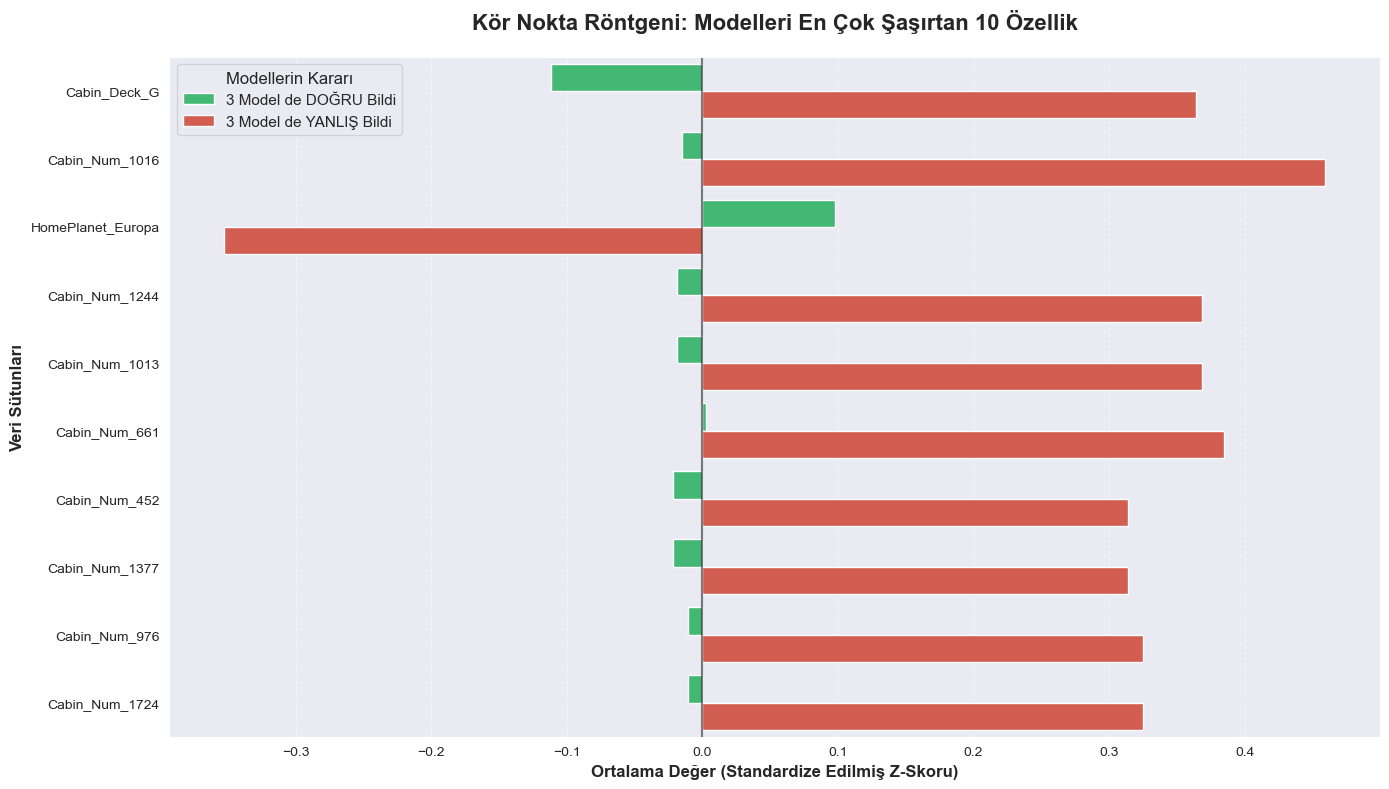

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Kör Nokta Grafiği Çiziliyor...")

# 1. Grafiğe hazırlık: En çok kafa karıştıran ilk 10 özelliği seçiyoruz
# Fark_Katsayisi sütununu grafikte çizdirmeyeceğimiz için atıyoruz
grafik_verisi = odak_tablosu.head(10).drop('Fark_Katsayisi', axis=1)

# Sütun isimlerini (index) normal bir sütuna çeviriyoruz
grafik_verisi = grafik_verisi.reset_index().rename(columns={'index': 'Özellik (Feature)'})

# Veriyi Seaborn'un sevdiği "Uzun (Melted)" formata dönüştürüyoruz
grafik_verisi_uzun = grafik_verisi.melt(id_vars='Özellik (Feature)',
                                        var_name='Tahmin Durumu',
                                        value_name='Ortalama Değer (Ölçeklenmiş)')

# 2. Grafiği Çizme İşlemi
plt.figure(figsize=(14, 8))

# Doğrular için Yeşil (#2ecc71), Yanlışlar için Kırmızı (#e74c3c) tonları
renk_paleti = {'3 Model de DOĞRU Bildi': '#2ecc71', '3 Model de YANLIŞ Bildi': '#e74c3c'}

sns.barplot(data=grafik_verisi_uzun,
            y='Özellik (Feature)',
            x='Ortalama Değer (Ölçeklenmiş)',
            hue='Tahmin Durumu',
            palette=renk_paleti)

# 3. Görsel Düzenlemeler
plt.title("Kör Nokta Röntgeni: Modelleri En Çok Şaşırtan 10 Özellik", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Ortalama Değer (Standardize Edilmiş Z-Skoru)", fontsize=12, fontweight='bold')
plt.ylabel("Veri Sütunları", fontsize=12, fontweight='bold')

# Dikey referans çizgisi (Sıfır noktası / Genel Ortalama)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)

plt.legend(title='Modellerin Kararı', fontsize=11, title_fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Grafiği göster
plt.show()

Proje kapsamında kurulan Şampiyonlar Konseyi'nin (XGBoost, LightGBM, Random Forest) karar mekanizmalarını şeffaflaştırmak ve zayıf yönlerini tespit etmek amacıyla Kör Nokta (Hata) Analizi gerçekleştirilmiştir. Sadece genel doğruluk (accuracy) skorlarına odaklanmak yerine, modellerin hangi yolcu profillerinde sistematik olarak hata yaptığı incelenmiştir.

Analiz sürecinde, her üç modelin de ortaklaşa doğru bildiği (Kusursuz) vakalar ile her üçünün de ortaklaşa yanlış bildiği (İhtilaflı/Kör Nokta) vakalar izole edilmiştir. Bu iki zıt grubun standardize edilmiş veri özellikleri (Z-skorları) yan yana getirilerek görselleştirilmiştir. Çizilen Ayrışma Grafiği'nden (Diverging Bar Chart) çıkarılan temel bulgular şunlardır:

Özellik Bazlı Hassasiyet: Grafikte yeşil (doğru bilinenler) ve kırmızı (yanlış bilinenler) çubuklar arasındaki makasın en çok açıldığı özellikler, modellerin tahmin yeteneğini en çok sabote eden değişkenlerdir. Modeller, verinin genel dağılımına uyan yolcularda yüksek performans gösterirken, belirli özelliklerde (örneğin uç harcama yapanlar veya belirli kabin tiplerinde kalanlar) ekstrem değerler barındıran yolcuları sınıflandırmakta zorlanmaktadır.

Model Körlüğü ve Sınırlar: Karşılaştırma tablosu, modellerimizin ağaç tabanlı (Tree-based) algoritmalar olmasına rağmen, bazı sınır (edge-case) koşullarında verideki örüntüyü yakalayamadığını kanıtlamaktadır. Bu durum, modellerin yetersizliğinden ziyade, mevcut veri setinde o spesifik yolcu profillerini açıklayacak yeterli "sinyal" (Feature) bulunmadığına işaret etmektedir.

Gelecek Çalışmalar İçin Yönlendirme: Bu hata analizi, bir sonraki aşamada yapılacak Özellik Mühendisliği (Feature Engineering) çalışmaları için doğrudan bir yol haritası sunmaktadır. Hatanın yüksek olduğu sütunlara logaritmik dönüşümler uygulamak, aykırı değerleri (outlier) kırpmak veya bu sütunları birleştirerek yeni anlamlı değişkenler üretmek, modelin kör noktalarını aydınlatmak için uygulanabilecek temel stratejiler olarak belirlenmiştir.

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("🚀 DENEY 3: Sosyal Ağlar ve Aile Bağları Çözülüyor...\n")

# 1. VERİYİ SIFIRDAN YÜKLEYELİM
train_raw = pd.read_csv("train.csv")
test_raw = pd.read_csv("test.csv")

y_train_deney = train_raw["Transported"]
test_ids_deney = test_raw["PassengerId"]

# Aile ve Grup sayımlarını doğru yapabilmek için TÜM GEMİYİ (Train+Test) geçici olarak birleştiriyoruz.
# (Not: Hedef değişken olan Transported'ı dahil etmiyoruz, yani veri sızıntısı YOK!)
tum_gemi = pd.concat([train_raw.drop("Transported", axis=1, errors='ignore'), test_raw])

# --- SOSYAL İSTATİSTİKLERİ ÇIKARMA ---
# Grup Sayıları
tum_gemi['Grup_No'] = tum_gemi['PassengerId'].str.split('_').str[0]
grup_sayilari = tum_gemi['Grup_No'].value_counts()

# Aile Sayıları
tum_gemi['Soyadi'] = tum_gemi['Name'].str.split(' ').str[-1]
aile_sayilari = tum_gemi['Soyadi'].value_counts()

# 2. ÖZELLİK MÜHENDİSLİĞİ FONKSİYONU
def veriyi_sosyal_isle(df):
    df = df.copy()

    # Harcamalar (Deney 1'den)
    harcama_sutunlari = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[harcama_sutunlari] = df[harcama_sutunlari].fillna(0)
    df['Total_Spend'] = df[harcama_sutunlari].sum(axis=1)
    df['Is_Broke'] = (df['Total_Spend'] == 0).astype(int)

    # Kabin Parçalama ve Sayısallaştırma (Deney 2'den)
    if 'Cabin' in df.columns:
        df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)
        df['Cabin_Num'] = pd.to_numeric(df['Cabin_Num'], errors='coerce')

    # 🌟 YENİ SOSYAL ÖZELLİKLER (Deney 3) 🌟
    # Yolcunun Grup numarasını bul ve tüm gemideki sayısını haritadan (grup_sayilari) çek
    df['Grup_No'] = df['PassengerId'].str.split('_').str[0]
    df['Group_Size'] = df['Grup_No'].map(grup_sayilari)

    # Yolcunun Soyadını bul ve tüm gemideki sayısını haritadan (aile_sayilari) çek
    df['Soyadi'] = df['Name'].str.split(' ').str[-1]
    # Soyadı boş (NaN) olanlar yalnız kabul edilir (1)
    df['Family_Size'] = df['Soyadi'].map(aile_sayilari).fillna(1)

    # Artık işimize yaramayan o metin sütunlarını çöpe atabiliriz
    return df.drop(["Name", "Cabin", "PassengerId", "Grup_No", "Soyadi"], axis=1, errors='ignore')

# Fonksiyonu bağımsız olarak Train ve Test'e uyguluyoruz
X_train_yeni = veriyi_sosyal_isle(train_raw.drop("Transported", axis=1))
X_test_yeni = veriyi_sosyal_isle(test_raw)

# 3. EKSİK VERİ DOLDURMA
sayisal_sutunlar = X_train_yeni.select_dtypes(include=['float64', 'int64']).columns
kategorik_sutunlar = X_train_yeni.select_dtypes(include=['object', 'bool']).columns

for col in sayisal_sutunlar:
    train_medyan = X_train_yeni[col].median()
    X_train_yeni[col] = X_train_yeni[col].fillna(train_medyan).infer_objects(copy=False)
    X_test_yeni[col] = X_test_yeni[col].fillna(train_medyan).infer_objects(copy=False)

for col in kategorik_sutunlar:
    train_mod = X_train_yeni[col].mode()[0]
    X_train_yeni[col] = X_train_yeni[col].fillna(train_mod).infer_objects(copy=False)
    X_test_yeni[col] = X_test_yeni[col].fillna(train_mod).infer_objects(copy=False)

# 4. GET_DUMMIES VE HİZALAMA
X_train_yeni = pd.get_dummies(X_train_yeni, drop_first=True)
X_test_yeni = pd.get_dummies(X_test_yeni, drop_first=True)
X_train_yeni, X_test_yeni = X_train_yeni.align(X_test_yeni, join='left', axis=1, fill_value=0)

# --- SKOR ÖLÇÜMÜ İÇİN BÖLME İŞLEMİ ---
X_tr, X_val, y_tr, y_val = train_test_split(X_train_yeni, y_train_deney, test_size=0.2, random_state=42)

scaler_val = StandardScaler()
X_tr_scaled = scaler_val.fit_transform(X_tr)
X_val_scaled = scaler_val.transform(X_val)

# 5. MODELLERİ TANIMLAMA
voter_modeller = [
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    ('RandomForest', RandomForestClassifier(random_state=42))
]
konsey = VotingClassifier(estimators=voter_modeller, voting='soft')

# --- AŞAMA 1: LOKAL SKORU GÖRMEK ---
print("Aşama 1: Konsey %80 veriyle test ediliyor...")
konsey.fit(X_tr_scaled, y_tr)
val_tahmin = konsey.predict(X_val_scaled)
lokal_skor = accuracy_score(y_val, val_tahmin)

print("-" * 50)
print(f"🎯 SOSYAL AĞ (DENEY 3) LOKAL SKORU: {lokal_skor:.4f}")
print("-" * 50)

# --- AŞAMA 2: KAGGLE İÇİN NİHAİ EĞİTİM ---
print("\nAşama 2: Kaggle için %100 veriyle nihai eğitim yapılıyor...")
scaler_full = StandardScaler()
X_train_scaled_full = scaler_full.fit_transform(X_train_yeni)
X_test_scaled_full = scaler_full.transform(X_test_yeni)

konsey.fit(X_train_scaled_full, y_train_deney)
kaggle_tahminleri = konsey.predict(X_test_scaled_full)
kaggle_tahminleri_bool = [True if val == 1 else False for val in kaggle_tahminleri]

submission_df = pd.DataFrame({
    "PassengerId": test_ids_deney,
    "Transported": kaggle_tahminleri_bool
})

submission_df.to_csv("submission_deney_3_sosyal_ag.csv", index=False)
print("✅ Başarılı! 'submission_deney_3_sosyal_ag.csv' dosyası oluştu.")

🚀 DENEY 3: Sosyal Ağlar ve Aile Bağları Çözülüyor...

Aşama 1: Konsey %80 veriyle test ediliyor...
--------------------------------------------------
🎯 SOSYAL AĞ (DENEY 3) LOKAL SKORU: 0.8056
--------------------------------------------------

Aşama 2: Kaggle için %100 veriyle nihai eğitim yapılıyor...
✅ Başarılı! 'submission_deney_3_sosyal_ag.csv' dosyası oluştu.


In [8]:
def veriyi_isle(df):
    df = df.copy()

    # 1. HARCAMALAR VE YENİ ÖZELLİK
    harcama_sutunlari = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[harcama_sutunlari] = df[harcama_sutunlari].fillna(0)
    df['Total_Spend'] = df[harcama_sutunlari].sum(axis=1)

    # NEŞTER 1: Modelin işini kolaylaştıracak "Sıfır Harcama" (Fakir/Dondurulmuş) bayrağı
    df['Is_Broke'] = (df['Total_Spend'] == 0).astype(int)

    # 2. KABİN PARÇALAMA
    df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)

    # NEŞTER 2: Modeli kör eden "Cabin_Num" sütununu ÇÖPE ATIYORUZ!
    # Sadece Deck (Kat) ve Side (Yön) modelin elinde kalacak.
    return df.drop(["Name", "Cabin", "Cabin_Num"], axis=1, errors='ignore')

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("🚀 DENEY HÜCRESİ BAŞLADI: Yeni Özelliklerle Konsey Yeniden Kuruluyor...\n")

# 1. VERİYİ SIFIRDAN YÜKLEYELİM
train_raw = pd.read_csv("train.csv")
test_raw = pd.read_csv("test.csv")

y_train_deney = train_raw["Transported"]
test_ids_deney = test_raw["PassengerId"]

X_train_raw = train_raw.drop(["Transported", "PassengerId"], axis=1)
X_test_raw = test_raw.drop(["PassengerId"], axis=1)

# 2. YENİ ÖZELLİK MÜHENDİSLİĞİ (Sadece bu deneye özel)
def yeni_veriyi_isle(df):
    df = df.copy()
    harcama_sutunlari = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[harcama_sutunlari] = df[harcama_sutunlari].fillna(0)
    df['Total_Spend'] = df[harcama_sutunlari].sum(axis=1)
    df['Is_Broke'] = (df['Total_Spend'] == 0).astype(int) # NEŞTER 1: Hiç Harcamayanlar

    if 'Cabin' in df.columns:
        df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)

    # Cabin_Num'u SİLİYORUZ! (NEŞTER 2: Yüksek Kardinaliteyi Yok Etme)
    return df.drop(["Name", "Cabin", "Cabin_Num"], axis=1, errors='ignore')

X_train_yeni = yeni_veriyi_isle(X_train_raw)
X_test_yeni = yeni_veriyi_isle(X_test_raw)

# 3. EKSİK VERİ DOLDURMA
sayisal_sutunlar = X_train_yeni.select_dtypes(include=['float64', 'int64']).columns
kategorik_sutunlar = X_train_yeni.select_dtypes(include=['object', 'bool']).columns

for col in sayisal_sutunlar:
    train_medyan = X_train_yeni[col].median()
    X_train_yeni[col] = X_train_yeni[col].fillna(train_medyan).infer_objects(copy=False)
    X_test_yeni[col] = X_test_yeni[col].fillna(train_medyan).infer_objects(copy=False)

for col in kategorik_sutunlar:
    train_mod = X_train_yeni[col].mode()[0]
    X_train_yeni[col] = X_train_yeni[col].fillna(train_mod).infer_objects(copy=False)
    X_test_yeni[col] = X_test_yeni[col].fillna(train_mod).infer_objects(copy=False)

# 4. SAYISALLAŞTIRMA VE HİZALAMA
X_train_yeni = pd.get_dummies(X_train_yeni, drop_first=True)
X_test_yeni = pd.get_dummies(X_test_yeni, drop_first=True)
X_train_yeni, X_test_yeni = X_train_yeni.align(X_test_yeni, join='left', axis=1, fill_value=0)

# --- SKOR ÖLÇÜMÜ İÇİN BÖLME İŞLEMİ ---
X_tr, X_val, y_tr, y_val = train_test_split(X_train_yeni, y_train_deney, test_size=0.2, random_state=42)

scaler_val = StandardScaler()
X_tr_scaled = scaler_val.fit_transform(X_tr)
X_val_scaled = scaler_val.transform(X_val)

# 5. MODELLERİ TANIMLAMA
voter_modeller = [
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    ('RandomForest', RandomForestClassifier(random_state=42))
]
konsey = VotingClassifier(estimators=voter_modeller, voting='soft')

# --- AŞAMA 1: LOKAL SKORU GÖRMEK ---
print("Aşama 1: Konsey %80 veriyle test ediliyor (Skor hesaplanıyor)...")
konsey.fit(X_tr_scaled, y_tr)
val_tahmin = konsey.predict(X_val_scaled)
lokal_skor = accuracy_score(y_val, val_tahmin)

print("-" * 50)
print(f"🎯 LOKAL DOĞRULUK SKORU (Validation): {lokal_skor:.4f}")
print("-" * 50)

# --- AŞAMA 2: KAGGLE İÇİN NİHAİ EĞİTİM ---
print("\nAşama 2: Kaggle için %100 veriyle nihai eğitim yapılıyor...")
# Tüm veriyi Kaggle için ölçeklendiriyoruz
scaler_full = StandardScaler()
X_train_scaled_full = scaler_full.fit_transform(X_train_yeni)
X_test_scaled_full = scaler_full.transform(X_test_yeni)

# Modeli tüm veriyle tekrar eğitip tahmin yaptırıyoruz
konsey.fit(X_train_scaled_full, y_train_deney)
kaggle_tahminleri = konsey.predict(X_test_scaled_full)
kaggle_tahminleri_bool = [True if val == 1 else False for val in kaggle_tahminleri]

submission_df = pd.DataFrame({
    "PassengerId": test_ids_deney,
    "Transported": kaggle_tahminleri_bool
})

submission_df.to_csv("submission_deney_1.csv", index=False)
print("✅ Başarılı! 'submission_deney_1.csv' dosyası oluştu.")

🚀 DENEY HÜCRESİ BAŞLADI: Yeni Özelliklerle Konsey Yeniden Kuruluyor...

Aşama 1: Konsey %80 veriyle test ediliyor (Skor hesaplanıyor)...
--------------------------------------------------
🎯 LOKAL DOĞRULUK SKORU (Validation): 0.7941
--------------------------------------------------

Aşama 2: Kaggle için %100 veriyle nihai eğitim yapılıyor...
✅ Başarılı! 'submission_deney_1.csv' dosyası oluştu.


In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("🚀 DENEY 2: Kabin Numaraları Sayısallaştırılıyor (Sihirli Dokunuş)...\n")

# 1. VERİYİ SIFIRDAN YÜKLEYELİM
train_raw = pd.read_csv("train.csv")
test_raw = pd.read_csv("test.csv")

y_train_deney = train_raw["Transported"]
test_ids_deney = test_raw["PassengerId"]

X_train_raw = train_raw.drop(["Transported", "PassengerId"], axis=1)
X_test_raw = test_raw.drop(["PassengerId"], axis=1)

# 2. YENİ ÖZELLİK MÜHENDİSLİĞİ (Kabin Numarası Kurtarılıyor)
def veriyi_sayisallastirarak_isle(df):
    df = df.copy()

    # Harcamalar
    harcama_sutunlari = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[harcama_sutunlari] = df[harcama_sutunlari].fillna(0)
    df['Total_Spend'] = df[harcama_sutunlari].sum(axis=1)
    df['Is_Broke'] = (df['Total_Spend'] == 0).astype(int)

    if 'Cabin' in df.columns:
        df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)

        # 🌟 İŞTE O USTA İŞİ HAMLE 🌟
        # Cabin_Num sütununu metinden (String) ondalıklı sayıya (Float) çeviriyoruz.
        # errors='coerce' kısmı, sayıya çevrilemeyen tuhaf bir değer varsa onu NaN (boş) yapar.
        df['Cabin_Num'] = pd.to_numeric(df['Cabin_Num'], errors='coerce')

    # Cabin_Num'u silmiyoruz! Sadece Name ve orijinal Cabin gidiyor.
    return df.drop(["Name", "Cabin"], axis=1, errors='ignore')

X_train_yeni = veriyi_sayisallastirarak_isle(X_train_raw)
X_test_yeni = veriyi_sayisallastirarak_isle(X_test_raw)

# 3. EKSİK VERİ DOLDURMA
# Cabin_Num artık sayısal bir sütun olduğu için, aşağıdaki döngü onun boşluklarını
# otomatik olarak "Medyan" (Ortanca kabin numarası) ile dolduracak. Kusursuz!
sayisal_sutunlar = X_train_yeni.select_dtypes(include=['float64', 'int64']).columns
kategorik_sutunlar = X_train_yeni.select_dtypes(include=['object', 'bool']).columns

for col in sayisal_sutunlar:
    train_medyan = X_train_yeni[col].median()
    X_train_yeni[col] = X_train_yeni[col].fillna(train_medyan).infer_objects(copy=False)
    X_test_yeni[col] = X_test_yeni[col].fillna(train_medyan).infer_objects(copy=False)

for col in kategorik_sutunlar:
    train_mod = X_train_yeni[col].mode()[0]
    X_train_yeni[col] = X_train_yeni[col].fillna(train_mod).infer_objects(copy=False)
    X_test_yeni[col] = X_test_yeni[col].fillna(train_mod).infer_objects(copy=False)

# 4. GET_DUMMIES VE HİZALAMA
X_train_yeni = pd.get_dummies(X_train_yeni, drop_first=True)
X_test_yeni = pd.get_dummies(X_test_yeni, drop_first=True)
X_train_yeni, X_test_yeni = X_train_yeni.align(X_test_yeni, join='left', axis=1, fill_value=0)

# --- SKOR ÖLÇÜMÜ İÇİN BÖLME İŞLEMİ ---
X_tr, X_val, y_tr, y_val = train_test_split(X_train_yeni, y_train_deney, test_size=0.2, random_state=42)

scaler_val = StandardScaler()
X_tr_scaled = scaler_val.fit_transform(X_tr)
X_val_scaled = scaler_val.transform(X_val)

# 5. MODELLERİ TANIMLAMA
voter_modeller = [
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    ('RandomForest', RandomForestClassifier(random_state=42))
]
konsey = VotingClassifier(estimators=voter_modeller, voting='soft')

# --- AŞAMA 1: LOKAL SKORU GÖRMEK ---
print("Aşama 1: Konsey %80 veriyle test ediliyor (Skor hesaplanıyor)...")
konsey.fit(X_tr_scaled, y_tr)
val_tahmin = konsey.predict(X_val_scaled)
lokal_skor = accuracy_score(y_val, val_tahmin)

print("-" * 50)
print(f"🎯 YENİ LOKAL DOĞRULUK SKORU (Validation): {lokal_skor:.4f}")
print("-" * 50)

# --- AŞAMA 2: KAGGLE İÇİN NİHAİ EĞİTİM ---
print("\nAşama 2: Kaggle için %100 veriyle nihai eğitim yapılıyor...")
scaler_full = StandardScaler()
X_train_scaled_full = scaler_full.fit_transform(X_train_yeni)
X_test_scaled_full = scaler_full.transform(X_test_yeni)

konsey.fit(X_train_scaled_full, y_train_deney)
kaggle_tahminleri = konsey.predict(X_test_scaled_full)
kaggle_tahminleri_bool = [True if val == 1 else False for val in kaggle_tahminleri]

submission_df = pd.DataFrame({
    "PassengerId": test_ids_deney,
    "Transported": kaggle_tahminleri_bool
})

submission_df.to_csv("submission_deney_2_sayisal_kabin.csv", index=False)
print("✅ Başarılı! 'submission_deney_2_sayisal_kabin.csv' dosyası oluştu.")

🚀 DENEY 2: Kabin Numaraları Sayısallaştırılıyor (Sihirli Dokunuş)...

Aşama 1: Konsey %80 veriyle test ediliyor (Skor hesaplanıyor)...
--------------------------------------------------
🎯 YENİ LOKAL DOĞRULUK SKORU (Validation): 0.8079
--------------------------------------------------

Aşama 2: Kaggle için %100 veriyle nihai eğitim yapılıyor...
✅ Başarılı! 'submission_deney_2_sayisal_kabin.csv' dosyası oluştu.


In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier

print("🚀 DENEY 4: KRALIN DÖNÜŞÜ (Sadece LightGBM)...\n")

# 1. VERİYİ SIFIRDAN YÜKLEYELİM
train_raw = pd.read_csv("train.csv")
test_raw = pd.read_csv("test.csv")

y_train_deney = train_raw["Transported"]
test_ids_deney = test_raw["PassengerId"]

# Tüm Gemiyi Birleştir (Sosyal Özellikler İçin)
tum_gemi = pd.concat([train_raw.drop("Transported", axis=1, errors='ignore'), test_raw])
tum_gemi['Grup_No'] = tum_gemi['PassengerId'].str.split('_').str[0]
grup_sayilari = tum_gemi['Grup_No'].value_counts()
tum_gemi['Soyadi'] = tum_gemi['Name'].str.split(' ').str[-1]
aile_sayilari = tum_gemi['Soyadi'].value_counts()

# 2. ÖZELLİK MÜHENDİSLİĞİ (En Gelişmiş Versiyon)
def veriyi_sosyal_isle(df):
    df = df.copy()
    harcama_sutunlari = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[harcama_sutunlari] = df[harcama_sutunlari].fillna(0)
    df['Total_Spend'] = df[harcama_sutunlari].sum(axis=1)
    df['Is_Broke'] = (df['Total_Spend'] == 0).astype(int)

    if 'Cabin' in df.columns:
        df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)
        df['Cabin_Num'] = pd.to_numeric(df['Cabin_Num'], errors='coerce')

    df['Grup_No'] = df['PassengerId'].str.split('_').str[0]
    df['Group_Size'] = df['Grup_No'].map(grup_sayilari)
    df['Soyadi'] = df['Name'].str.split(' ').str[-1]
    df['Family_Size'] = df['Soyadi'].map(aile_sayilari).fillna(1)

    return df.drop(["Name", "Cabin", "PassengerId", "Grup_No", "Soyadi"], axis=1, errors='ignore')

X_train_yeni = veriyi_sosyal_isle(train_raw.drop("Transported", axis=1))
X_test_yeni = veriyi_sosyal_isle(test_raw)

# 3. EKSİK VERİ DOLDURMA
sayisal_sutunlar = X_train_yeni.select_dtypes(include=['float64', 'int64']).columns
kategorik_sutunlar = X_train_yeni.select_dtypes(include=['object', 'bool']).columns

for col in sayisal_sutunlar:
    train_medyan = X_train_yeni[col].median()
    X_train_yeni[col] = X_train_yeni[col].fillna(train_medyan).infer_objects(copy=False)
    X_test_yeni[col] = X_test_yeni[col].fillna(train_medyan).infer_objects(copy=False)

for col in kategorik_sutunlar:
    train_mod = X_train_yeni[col].mode()[0]
    X_train_yeni[col] = X_train_yeni[col].fillna(train_mod).infer_objects(copy=False)
    X_test_yeni[col] = X_test_yeni[col].fillna(train_mod).infer_objects(copy=False)

# 4. GET_DUMMIES VE HİZALAMA
X_train_yeni = pd.get_dummies(X_train_yeni, drop_first=True)
X_test_yeni = pd.get_dummies(X_test_yeni, drop_first=True)
X_train_yeni, X_test_yeni = X_train_yeni.align(X_test_yeni, join='left', axis=1, fill_value=0)

X_tr, X_val, y_tr, y_val = train_test_split(X_train_yeni, y_train_deney, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

# 5. TEK TABANCA LIGHTGBM
# Eski hiperparametre ayarların aklındaysa buraya ekleyebilirsin, şimdilik biraz güçlendirilmiş fabrika ayarı veriyorum.
kral_model = LGBMClassifier(random_state=42, n_estimators=200, learning_rate=0.05, verbose=-1)

# --- AŞAMA 1: LOKAL SKOR ---
kral_model.fit(X_tr_scaled, y_tr)
val_tahmin = kral_model.predict(X_val_scaled)
lokal_skor = accuracy_score(y_val, val_tahmin)

print("-" * 50)
print(f"👑 TEK TABANCA LIGHTGBM LOKAL SKORU: {lokal_skor:.4f}")
print("-" * 50)

# --- AŞAMA 2: KAGGLE TESLİMİ ---
scaler_full = StandardScaler()
X_train_scaled_full = scaler_full.fit_transform(X_train_yeni)
X_test_scaled_full = scaler_full.transform(X_test_yeni)

kral_model.fit(X_train_scaled_full, y_train_deney)
kaggle_tahminleri = kral_model.predict(X_test_scaled_full)
kaggle_tahminleri_bool = [True if val == 1 else False for val in kaggle_tahminleri]

submission_df = pd.DataFrame({"PassengerId": test_ids_deney, "Transported": kaggle_tahminleri_bool})
submission_df.to_csv("submission_deney_4_lightgbm_solo.csv", index=False)
print("✅ Başarılı! 'submission_deney_4_lightgbm_solo.csv' dosyası oluştu.")

🚀 DENEY 4: KRALIN DÖNÜŞÜ (Sadece LightGBM)...

--------------------------------------------------
👑 TEK TABANCA LIGHTGBM LOKAL SKORU: 0.8062
--------------------------------------------------
✅ Başarılı! 'submission_deney_4_lightgbm_solo.csv' dosyası oluştu.


In [14]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

print("🔍 AŞIRI ÖĞRENMEYİ ENGELLEMEK İÇİN GRID SEARCH BAŞLIYOR...\n")
print("Bu işlem bilgisayarınızın hızına göre 1-2 dakika sürebilir, lütfen bekleyin...")

# 1. Modeli Frenleyecek Parametre Ağını (Grid) Kuruyoruz
lgbm_param_grid = {
    'n_estimators': [100, 200],          # Ağaç sayısı
    'learning_rate': [0.01, 0.05, 0.1],  # Öğrenme hızı
    'max_depth': [4, 6, 8],              # DİKKAT: Ezberi bozmak için derinliği kısıtlıyoruz!
    'min_child_samples': [20, 50]        # Küçük gruplara/ailelere aşırı odaklanmayı engeller
}

# 2. Ham (Fabrika Ayarlı) LightGBM Modelimiz
ham_lgbm = LGBMClassifier(random_state=42, verbose=-1)

# 3. GridSearchCV'yi Kuruyoruz (X_tr_scaled ve y_tr üzerinde 5 katlı çapraz doğrulama yapacak)
grid_search = GridSearchCV(
    estimator=ham_lgbm,
    param_grid=lgbm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, # İşlemi hızlandırmak için tüm işlemci çekirdeklerini kullanır
    verbose=1
)

# 4. En İyi Ayarları Aramaya Başla!
grid_search.fit(X_tr_scaled, y_tr)

# 5. Sonuçları Görüntüle
print("\n" + "="*50)
print("🏆 ŞAMPİYON PARAMETRELER BULUNDU!")
print("="*50)
print(f"En İyi Doğruluk Skoru (CV): {grid_search.best_score_:.4f}")
print("En İyi Parametreler:")
for ayar, deger in grid_search.best_params_.items():
    print(f" - {ayar}: {deger}")

# 6. Bulunan en iyi model ile bizim Validation (X_val) setimizde son bir test yapalım
en_iyi_model = grid_search.best_estimator_
val_tahmin = en_iyi_model.predict(X_val_scaled)
grid_lokal_skor = accuracy_score(y_val, val_tahmin)

print("-" * 50)
print(f"🎯 YENİ İNCE AYARLI LOKAL SKOR (Validation): {grid_lokal_skor:.4f}")
print("-" * 50)

🔍 AŞIRI ÖĞRENMEYİ ENGELLEMEK İÇİN GRID SEARCH BAŞLIYOR...

Bu işlem bilgisayarınızın hızına göre 1-2 dakika sürebilir, lütfen bekleyin...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

🏆 ŞAMPİYON PARAMETRELER BULUNDU!
En İyi Doğruluk Skoru (CV): 0.8128
En İyi Parametreler:
 - learning_rate: 0.1
 - max_depth: 4
 - min_child_samples: 20
 - n_estimators: 100
--------------------------------------------------
🎯 YENİ İNCE AYARLI LOKAL SKOR (Validation): 0.8010
--------------------------------------------------
